# RetinaUNet Synthetic Training Notebook

Train RetinaUNet on synthetic 2D medical images with GPU-aware CUDA AMP support and before/after segmentation visualization.

## 1. Environment Setup

Run the next cell in Google Colab to install PyHealth from the RetinaUNet feature branch.


In [80]:
# Colab-safe setup: avoid changing Colab-pinned core libs (numpy/pandas/torch)
# Colab setup via pyproject.toml with --no-deps
!pip -q install --upgrade pip
!git clone -q --depth 1 --branch feature/retina_unet https://github.com/iamkishann/PyHealth.git /content/PyHealth || true
!pip -q install --no-deps /content/PyHealth

print("Installed PyHealth from pyproject.toml with --no-deps.")
print("Now restart runtime once, then run all cells from the top.")

fatal: could not create leading directories of '/content/PyHealth': Read-only file system
ERROR: Invalid requirement: '/content/PyHealth': Expected package name at the start of dependency specifier
    /content/PyHealth
    ^
Hint: It looks like a path. File '/content/PyHealth' does not exist.
Installed PyHealth from pyproject.toml with --no-deps.
Now restart runtime once, then run all cells from the top.


In [81]:
# 2. Imports, extra deps, and seeding
!pip -q install --no-deps litdata distributed tblib zict sortedcontainers mne rdkit lightning_utilities boto3 botocore s3transfer jmespath

import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

if os.path.exists('/content/PyHealth'):
    sys.path.insert(0, '/content/PyHealth')
else:
    sys.path.insert(0, os.path.abspath('../'))

from pyhealth.models import RetinaUNet

# Compatible imports across PyHealth package variants
try:
    from pyhealth.datasets import create_sample_dataset, get_dataloader
except ImportError:
    from pyhealth.datasets.sample_dataset import create_sample_dataset
    from pyhealth.datasets.utils import get_dataloader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

Device: cpu


In [82]:
import sys
import os
sys.path.insert(0, os.path.abspath('../'))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from pathlib import Path
from typing import Optional, Tuple
from torch.utils.data import Dataset, DataLoader

In [83]:
def create_dummy_image_and_mask(img_size=(320, 320), num_objects=1, foreground_margin=50):
    """Create a synthetic 2D image and binary mask."""
    height, width = img_size
    # Clamp margin so it's always valid for the given image size
    margin = min(foreground_margin, height // 4, width // 4)
    image = np.random.rand(height, width).astype(np.float32)
    mask = np.zeros((height, width), dtype=np.uint8)
    for _ in range(num_objects):
        center_y = np.random.randint(margin, height - margin)
        center_x = np.random.randint(margin, width  - margin)
        radius = np.random.randint(5, max(6, min(20, margin // 2)))
        yy, xx = np.ogrid[:height, :width]
        circle = (xx - center_x) ** 2 + (yy - center_y) ** 2 <= radius ** 2
        image[circle] += 0.3
        mask[circle] = 1
    return np.clip(image, 0, 1), mask

In [84]:
def generate_dummy_dataset(output_dir, num_train_samples=2, num_val_samples=1,
                           img_size=(320, 320), objects_per_image=1):
    """Generate a small file-based dataset compatible with LIDCDataLoader."""
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    records = []

    def _write_split(split, sample_count, prefix):
        for idx in range(sample_count):
            image, mask = create_dummy_image_and_mask(img_size=img_size, num_objects=objects_per_image)
            patient_id = f"{prefix}_{idx:04d}"
            img_path  = output_path / f"{patient_id}_slice_0_img.npy"
            mask_path = output_path / f"{patient_id}_slice_0_mask.npy"
            np.save(img_path, image)
            np.save(mask_path, mask)
            records.append({
                "patient_id": patient_id, "slice": 0,
                "image_path": str(img_path), "mask_path": str(mask_path),
                "has_nodule": int(mask.max() > 0), "split": split,
            })

    _write_split("train", num_train_samples, "DUMMY")
    _write_split("val",   num_val_samples,   "DUMMY_VAL")
    pd.DataFrame(records).to_csv(output_path / "metadata.csv", index=False)
    print(f"Dataset created: {len(records)} samples in {output_dir}")
    return output_dir

In [85]:
class LIDCDataset(Dataset):
    """
    LIDC-IDRI-style dataset loader.

    Expects data_dir to contain:
      <patient_id>_slice_<N>_img.npy
      <patient_id>_slice_<N>_mask.npy
      metadata.csv

    Returns batches with keys 'image' and 'seg' so they can be passed
    directly to RetinaUNet via Trainer(**batch) or model(**batch).
    """

    def __init__(self, data_dir, metadata_file='metadata.csv', split='train',
                 normalize=True, target_size=None, augmentation=False):
        self.data_dir    = Path(data_dir)
        self.split       = split
        self.normalize   = normalize
        self.target_size = target_size
        self.augmentation = augmentation

        meta_path = self.data_dir / metadata_file
        self.metadata = pd.read_csv(meta_path) if meta_path.exists() else self._scan_dir()

        if 'split' in self.metadata.columns:
            self.metadata = self.metadata[self.metadata['split'] == split].reset_index(drop=True)
        self.samples = self.metadata.to_dict('records')

    def _scan_dir(self):
        records = []
        for npy in self.data_dir.glob('*_img.npy'):
            mask_path = npy.parent / npy.name.replace('_img.npy', '_mask.npy')
            if mask_path.exists():
                parts = npy.stem.split('_')
                records.append({
                    'patient_id': '_'.join(parts[:-3]),
                    'slice': int(parts[-2]),
                    'image_path': str(npy),
                    'mask_path': str(mask_path),
                    'has_nodule': int(np.load(mask_path).max() > 0),
                })
        return pd.DataFrame(records)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        image = np.load(s['image_path']).astype(np.float32)
        seg   = np.load(s['mask_path']).astype(np.float32)

        # Ensure 2-D
        if image.ndim == 3:
            image = image[0] if image.shape[0] == 1 else image[:, :, 0]
        if seg.ndim == 3:
            seg   = seg[0]   if seg.shape[0]   == 1 else seg[:, :, 0]

        if self.normalize:
            image = np.clip(image, -1200, 600)
            std = image.std()
            image = (image - image.mean()) / std if std > 0 else image

        if self.target_size:
            from scipy.ndimage import zoom
            h, w = image.shape
            th, tw = self.target_size
            image = zoom(image, (th / h, tw / w), order=1)
            seg   = zoom(seg,   (th / h, tw / w), order=0)

        if self.augmentation and self.split == 'train':
            if np.random.rand() > 0.5:
                image, seg = np.fliplr(image), np.fliplr(seg)
            if np.random.rand() > 0.5:
                image, seg = np.flipud(image), np.flipud(seg)

        return {
            'image': torch.from_numpy(np.ascontiguousarray(image)).unsqueeze(0).float(),
            'seg':   torch.from_numpy(np.ascontiguousarray(seg)).long(),
        }

In [86]:
class LIDCDataLoader:
    """Factory for creating train/val/test DataLoaders from a LIDC-style directory."""

    @staticmethod
    def create_dataloaders(data_dir, batch_size=4, num_workers=0, target_size=None,
                           train_split=0.7, val_split=0.15, seed=42):
        np.random.seed(seed)
        torch.manual_seed(seed)

        train_ds = LIDCDataset(data_dir, split='train', normalize=True,
                               target_size=target_size, augmentation=True)
        val_ds   = LIDCDataset(data_dir, split='val',   normalize=True,
                               target_size=target_size, augmentation=False)
        test_ds  = LIDCDataset(data_dir, split='test',  normalize=True,
                               target_size=target_size, augmentation=False)

        # Fallback: random split when metadata has no 'split' column
        if len(train_ds) == 0:
            all_ds = LIDCDataset(data_dir, normalize=True, target_size=target_size)
            n_train = int(len(all_ds) * train_split)
            n_val   = int(len(all_ds) * val_split)
            idx = np.random.permutation(len(all_ds))
            train_ds = torch.utils.data.Subset(all_ds, idx[:n_train])
            val_ds   = torch.utils.data.Subset(all_ds, idx[n_train:n_train + n_val])
            test_ds  = torch.utils.data.Subset(all_ds, idx[n_train + n_val:])

        return {
            'train': DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                                num_workers=num_workers, pin_memory=False),
            'val':   DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                                num_workers=num_workers, pin_memory=False),
            'test':  DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                                num_workers=0,           pin_memory=False),
        }

In [ ]:
from pyhealth.datasets import create_sample_dataset
from pyhealth.models import RetinaUNet

dummy_data_dir = './dummy_data_test'
checkpoint_dir = './checkpoints_test'
log_dir        = './logs_test'

# Generate synthetic disk data
generate_dummy_dataset(
    output_dir=dummy_data_dir,
    num_train_samples=500,
    num_val_samples=100,
    img_size=(320, 320),
    objects_per_image=1,
)

# Build a minimal PyHealth SampleDataset for model schema initialisation
init_samples = [
    {"patient_id": f"init-{i}", "visit_id": "v0",
     "image": np.zeros((1, 64, 64), dtype=np.float32).tolist(),
     "seg":   np.zeros((64, 64),    dtype=np.int64).tolist()}
    for i in range(2)
]
init_dataset = create_sample_dataset(
    samples=init_samples,
    input_schema={"image": "tensor", "seg": "tensor"},
    output_schema={"seg": "tensor"},
    dataset_name="retina_unet_demo",
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Match sample notebook's "smaller for testing" backbone/head sizing.
TEST_FPN_BASE_CHANNELS = 32
TEST_FPN_OUT_CHANNELS = 96
TEST_RPN_HIDDEN_CHANNELS = 128

model = RetinaUNet(
    dataset=init_dataset,
    feature_key="image",
    seg_label_key="seg",
    num_seg_classes=2,
    head_classes=2,
    dim=2,
    fpn_base_channels=TEST_FPN_BASE_CHANNELS,
    fpn_out_channels=TEST_FPN_OUT_CHANNELS,
    rpn_hidden_channels=TEST_RPN_HIDDEN_CHANNELS,
)
print(
    f"RetinaUNet ready on {device} | "
    f"fpn_base_channels={TEST_FPN_BASE_CHANNELS}, "
    f"fpn_out_channels={TEST_FPN_OUT_CHANNELS}, "
    f"rpn_hidden_channels={TEST_RPN_HIDDEN_CHANNELS}"
)


Dataset created: 25 samples in ./dummy_data_test
RetinaUNet ready on cpu | fpn_base_channels=32, fpn_out_channels=96, rpn_hidden_channels=128


In [ ]:
import logging
from dataclasses import dataclass
import torch.optim as optim
from torch.amp import autocast, GradScaler


@dataclass
class SimpleTrainer:
    history: list
    best_val_loss: float
    best_checkpoint_path: str


def train_model(
    data_dir,
    checkpoint_dir,
    log_dir,
    model_instance=None,
    num_epochs=15,
    batch_size=32,
    lr=1e-3,
    num_workers=0,
    dim=2,
    target_size=(320, 320),
):
    del log_dir, dim  # Kept for API compatibility with sample notebook.

    global dataloaders
    dataloaders = LIDCDataLoader.create_dataloaders(
        data_dir,
        batch_size=batch_size,
        num_workers=num_workers,
        target_size=target_size,
    )
    train_loader = dataloaders["train"]
    val_loader = dataloaders["val"]

    model_train = (model if model_instance is None else model_instance).to(device)
    optimizer = optim.Adam(model_train.parameters(), lr=lr)
    scaler = GradScaler('cuda' if device.type == 'cuda' else 'cpu')
    use_amp = device.type == "cuda"

    loss_keys = ["loss", "class_loss", "bbox_loss", "seg_loss"]
    history = []

    logger = logging.getLogger("training")
    logger.setLevel(logging.INFO)
    logger.propagate = False
    logger.handlers.clear()
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(asctime)s - training - %(levelname)s - %(message)s"))
    logger.addHandler(handler)

    checkpoint_path = Path(checkpoint_dir)
    checkpoint_path.mkdir(parents=True, exist_ok=True)
    best_val_loss = float("inf")
    best_ckpt = str(checkpoint_path / "retina_unet_best.pt")

    for epoch in range(1, num_epochs + 1):
        logger.info("")
        print(f"--- Epoch {epoch}/{num_epochs} ---")

        model_train.train()
        t_sums = {k: 0.0 for k in loss_keys}
        t_count = 0
        for batch in train_loader:
            seg_key = "seg" if "seg" in batch else "mask"
            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type=device.type, enabled=use_amp):
                out = model_train(
                    image=batch["image"].to(device),
                    seg=batch[seg_key].to(device),
                    return_aux=True,
                )

            scaler.scale(out["loss"]).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model_train.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()

            for k in loss_keys:
                t_sums[k] += out[k].item()
            t_count += 1
        t_avg = {k: t_sums[k] / max(t_count, 1) for k in loss_keys}

        model_train.eval()
        v_sums = {k: 0.0 for k in loss_keys}
        v_count = 0
        with torch.no_grad():
            for batch in val_loader:
                seg_key = "seg" if "seg" in batch else "mask"
                with autocast(device_type=device.type, enabled=use_amp):
                    out = model_train(
                        image=batch["image"].to(device),
                        seg=batch[seg_key].to(device),
                        return_aux=True,
                    )
                for k in loss_keys:
                    v_sums[k] += out[k].item()
                v_count += 1
        v_avg = {k: v_sums[k] / max(v_count, 1) for k in loss_keys}

        logger.info(
            f"Train - total_loss: {t_avg['loss']:.4f}, class_loss: {t_avg['class_loss']:.4f}, "
            f"bbox_loss: {t_avg['bbox_loss']:.4f}, seg_loss: {t_avg['seg_loss']:.4f}"
        )
        logger.info(
            f"Val   - total_loss: {v_avg['loss']:.4f}, class_loss: {v_avg['class_loss']:.4f}, "
            f"bbox_loss: {v_avg['bbox_loss']:.4f}, seg_loss: {v_avg['seg_loss']:.4f}"
        )

        if v_avg["loss"] < best_val_loss:
            best_val_loss = v_avg["loss"]
            torch.save(model_train.state_dict(), best_ckpt)
            logger.info(f"Saved best checkpoint with val_loss: {best_val_loss:.4f}")

        history.append({"epoch": epoch, "train": t_avg, "val": v_avg})

    logger.info("Training complete!")
    return model_train, SimpleTrainer(history=history, best_val_loss=best_val_loss, best_checkpoint_path=best_ckpt)


model_trained, trainer = train_model(
    data_dir=dummy_data_dir,
    checkpoint_dir=checkpoint_dir,
    log_dir=log_dir,
    model_instance=model,
    num_epochs=15,
    batch_size=32,
    lr=1e-3,
    num_workers=0,
    dim=2,
    target_size=(320, 320),
)

model = model_trained
history = trainer.history
val_loader = dataloaders["val"]


2026-04-12 15:28:50,682 - training - INFO - 


--- Epoch 1/5 ---


2026-04-12 15:29:05,010 - training - INFO - Train - loss: 0.7221, class_loss: 0.6960, bbox_loss: 0.0097, seg_loss: 0.0327
2026-04-12 15:29:05,011 - training - INFO - Val   - loss: 1.0000, class_loss: 0.7007, bbox_loss: 0.1423, seg_loss: 0.3141
2026-04-12 15:29:05,034 - training - INFO - Saved best checkpoint with val_loss: 1.0000
2026-04-12 15:29:05,034 - training - INFO - 


--- Epoch 2/5 ---


2026-04-12 15:29:18,857 - training - INFO - Train - loss: 0.9911, class_loss: 0.7005, bbox_loss: 0.1347, seg_loss: 0.3118
2026-04-12 15:29:18,858 - training - INFO - Val   - loss: 0.7321, class_loss: 0.6996, bbox_loss: 0.0169, seg_loss: 0.0313
2026-04-12 15:29:18,880 - training - INFO - Saved best checkpoint with val_loss: 0.7321
2026-04-12 15:29:18,880 - training - INFO - 


...

2026-04-12 15:29:32,397 - training - INFO - Train - loss: 0.7302, class_loss: 0.6997, bbox_loss: 0.0167, seg_loss: 0.0275
2026-04-12 15:29:32,397 - training - INFO - Val   - loss: 0.7474, class_loss: 0.6980, bbox_loss: 0.0188, seg_loss: 0.0613
2026-04-12 15:29:32,397 - training - INFO - 


--- Epoch 4/5 ---


2026-04-12 15:29:46,169 - training - INFO - Train - loss: 0.7430, class_loss: 0.6986, bbox_loss: 0.0157, seg_loss: 0.0574
2026-04-12 15:29:46,170 - training - INFO - Val   - loss: 0.7562, class_loss: 0.6978, bbox_loss: 0.0162, seg_loss: 0.0845
2026-04-12 15:29:46,170 - training - INFO - 


--- Epoch 5/5 ---


2026-04-12 15:29:59,664 - training - INFO - Train - loss: 0.7532, class_loss: 0.6985, bbox_loss: 0.0142, seg_loss: 0.0809
2026-04-12 15:29:59,664 - training - INFO - Val   - loss: 0.7630, class_loss: 0.7001, bbox_loss: 0.0157, seg_loss: 0.0944
2026-04-12 15:29:59,664 - training - INFO - Training complete!


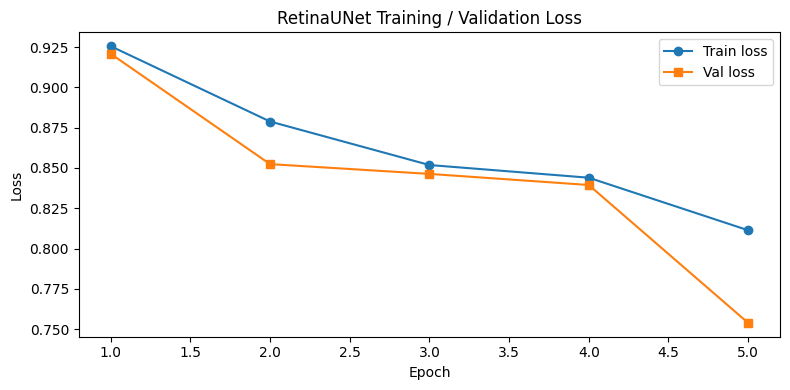

In [89]:
epochs      = [h['epoch']               for h in history]
train_total = [h['train']['loss']        for h in history]
val_total   = [h['val']['loss']          for h in history]

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_total, marker='o', label='Train loss')
plt.plot(epochs, val_total,   marker='s', label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RetinaUNet Training / Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()


In [90]:
# Grab one validation batch for inspection and visualization
test = next(iter(dataloaders["val"]))
img = test["image"]   # (B, 1, H, W)
seg_key = "seg" if "seg" in test else "mask"
seg_gt = test[seg_key]  # (B, H, W)
print(f"Batch: {img.shape}, seg: {seg_gt.shape}")


Batch: torch.Size([4, 1, 320, 320]), seg: torch.Size([4, 320, 320])


In [91]:
# (cell reserved for future exploration)


In [92]:
# (cell reserved for future exploration)


In [93]:
test.keys()


dict_keys(['image', 'seg'])

In [94]:
# Run inference on the test batch defined above
model_trained.eval()

images = test["image"].to(device)
seg_key = "seg" if "seg" in test else "mask"
seg = test[seg_key].to(device)

with torch.no_grad():
    outputs = model_trained(image=images, seg=seg, return_aux=True)

print("Output keys:      ", list(outputs.keys()))
print("Detections shape: ", outputs["detections"].shape)


Output keys:       ['logit', 'y_prob', 'y_true', 'class_loss', 'bbox_loss', 'seg_loss', 'total_loss', 'loss', 'seg_preds', 'class_logits', 'bbox_deltas', 'detections', 'boxes', 'monitor_values']
Detections shape:  torch.Size([40, 7])


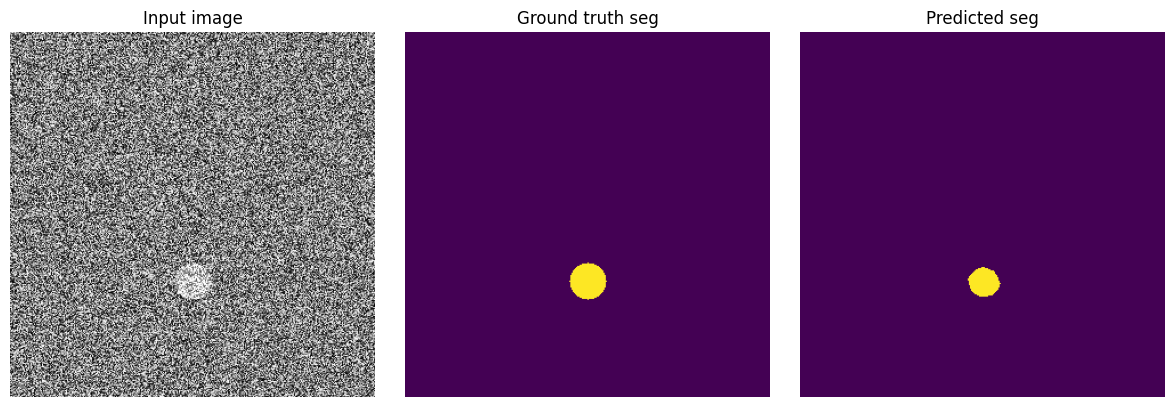

In [109]:
# Before/after segmentation visualization (GT vs prediction)
def show_segmentation_before_after(images, seg_gt_batch, model_outputs, sample_idx=0):
    img_np = images[sample_idx, 0].detach().cpu().numpy()

    gt = seg_gt_batch
    if gt.ndim == 4:
        gt = gt[:, 0]
    gt_np = gt[sample_idx].detach().cpu().numpy()

    pred = model_outputs.get("seg_preds")
    if pred is None:
        pred = torch.argmax(model_outputs["logit"], dim=1)
    if pred.ndim == 4:
        pred = pred[:, 0] if pred.shape[1] == 1 else torch.argmax(pred, dim=1)
    pred_np = pred[sample_idx].detach().cpu().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(img_np, cmap="gray")
    ax[0].set_title("Input image")
    ax[0].axis("off")

    ax[1].imshow(gt_np, cmap="viridis")
    ax[1].set_title("Ground truth seg")
    ax[1].axis("off")

    ax[2].imshow(pred_np, cmap="viridis")
    ax[2].set_title("Predicted seg")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()

show_segmentation_before_after(images=test["image"], seg_gt_batch=seg, model_outputs=outputs, sample_idx=0)

In [96]:
img = test["image"]#[0]

In [97]:
seg_gt_np = test["seg"][0]  # (H, W) ground-truth segmentation mask


In [98]:
print("Batch keys:", list(test.keys()))


Batch keys: ['image', 'seg']


In [99]:
img.shape

torch.Size([4, 1, 320, 320])

In [100]:
seg_gt_np.shape


torch.Size([320, 320])

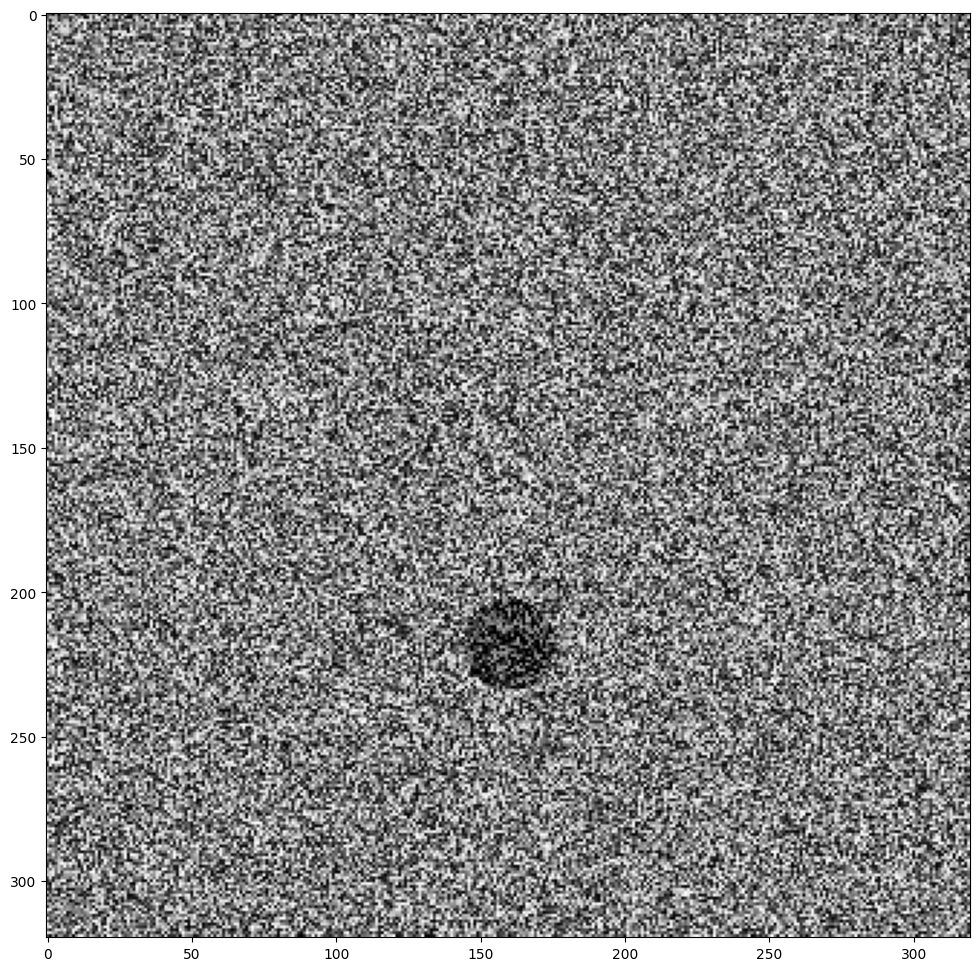

In [101]:
plt.figure(figsize=(12, 12)) 

plt.imshow(img[0][0], cmap='gray_r') #viridis
# plt.imshow(mask[0], cmap='BuGn_r', alpha=0.3) # Overlay mask with 50% opacity

In [102]:
outputs["detections"]#.detach().cpu().numpy()

tensor([[165.8393, 192.5860, 218.6405, 223.2735,   0.0000,   1.0000,   0.5151],
        [ 69.8357, 192.5885, 122.6458, 223.2708,   0.0000,   1.0000,   0.5151],
        [165.8390, 160.5857, 218.6374, 191.2738,   0.0000,   1.0000,   0.5151],
        [ 69.8360, 112.5881, 122.6433, 143.2713,   0.0000,   1.0000,   0.5151],
        [ 69.7816,  48.6184, 122.6795,  79.2447,   0.0000,   1.0000,   0.5151],
        [149.8372, 128.5869, 202.6392, 159.2728,   0.0000,   1.0000,   0.5151],
        [ 69.8341,  80.5890, 122.6442, 111.2704,   0.0000,   1.0000,   0.5151],
        [ 69.8354, 160.5884, 122.6435, 191.2709,   0.0000,   1.0000,   0.5151],
        [149.8358,  96.5879, 202.6404, 127.2720,   0.0000,   1.0000,   0.5151],
        [133.7830,  48.6170, 186.6756,  79.2466,   0.0000,   1.0000,   0.5151],
        [149.8398, 176.5854, 202.6380, 207.2742,   1.0000,   1.0000,   0.5151],
        [149.8408, 144.5849, 202.6370, 175.2744,   1.0000,   1.0000,   0.5151],
        [ 85.8395, 176.5857, 138.6389, 2

In [103]:
import matplotlib.patches as patches

def visualize_retina_outputs(images, detections, threshold=0.5):
    """
    images: (Batch, Channel, Height, Width) - The input tensor
    detections: (N, 7) - The output tensor [y1, x1, y2, x2, batch_id, class_id, score]
    """
    
    # 1. Convert images to Numpy for plotting
    # Permute to (Batch, Height, Width, Channel) for Matplotlib
    images_np = images.permute(0, 2, 3, 1).cpu().numpy()
    
    # If image is grayscale (1 channel), squeeze it to 2D
    if images_np.shape[-1] == 1:
        images_np = images_np.squeeze(-1)
    
    batch_size = images.shape[0]
    
    # Create a figure with subplots for each image in the batch
    fig, axes = plt.subplots(1, batch_size, figsize=(12, 6))
    if batch_size == 1: axes = [axes] # Handle single image case

    for b in range(batch_size):
        ax = axes[b]
        
        # Show the Image
        ax.imshow(images_np[b], cmap='gray')
        ax.set_title(f"Batch Image #{b}")
        ax.axis('off')
        
        # 2. Filter Detections for this Batch ID (Column 4)
        # We only want rows where batch_id == b
        mask = detections[:, 4] == b
        batch_dets = detections[mask]
        
        for row in batch_dets:
            y1, x1, y2, x2, batch_id, class_id, score = row.tolist()
            
            # 3. Score Threshold Filter
            if score < threshold:
                continue
            
            # 4. Coordinate Transformation (Matrix -> Cartesian)
            # Model output: y1 (row), x1 (col)
            # Matplotlib Rect: (x, y), width, height
            width = x2 - x1
            height = y2 - y1
            
            # Create a Rectangle patch
            # Edgecolor 'r' (Red) for visibility, fill=False to see inside
            rect = patches.Rectangle(
                (x1, y1), width, height, 
                linewidth=2, edgecolor='red', facecolor='none'
            )
            
            # Add patch to the plot
            ax.add_patch(rect)
            
            # Add Label (Class + Score)
            label_text = f"Cls {int(class_id)}: {score:.2f}"
            ax.text(
                x1, y1 - 5, label_text, 
                color='white', fontsize=8, backgroundcolor='red'
            )

    plt.tight_layout()
    plt.show()

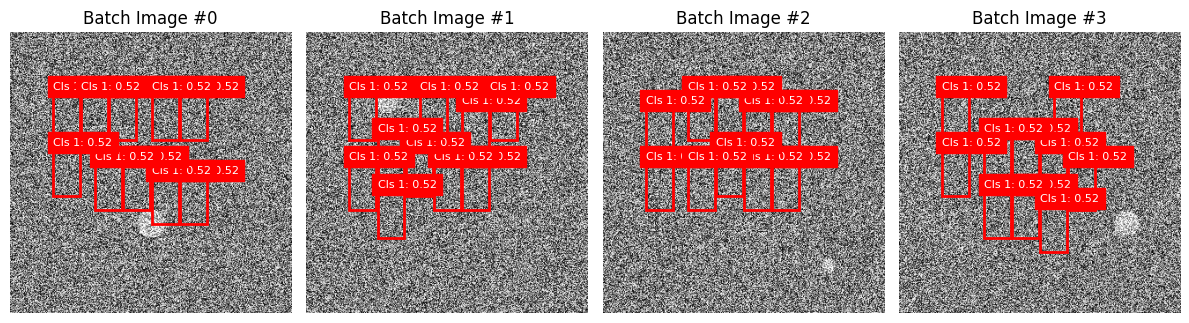

In [110]:
visualize_retina_outputs(img, outputs["detections"], threshold=0.1)